# The Multi-Agent Tiger Game

The Multi-Agent Tiger Game extends the classic single-agent Tiger Game to a scenario involving two decision makers facing the same pair of closed doors. As before, one door conceals a valuable prize (worth +10) while the other hides a dangerous tiger (worth -100). Each agent can choose from three actions:

1. **Open Left Door (OL)**: Open the left door to claim what's behind it
2. **Open Right Door (OR)**: Open the right door to claim what's behind it
3. **Listen (L)**: Listen for the tiger's growl to gain information (costs -1)

The multi-agent version introduces several key complexities:

**Coupled Dynamics**: If either agent opens a door, the tiger's location is reset randomly for the next time step, affecting both agents. This means one agent's actions can invalidate the other agent's accumulated information.

**Enhanced Observations**: Beyond hearing tiger growls (with ~85% accuracy), agents can now hear door creaks that indicate the other agent's actions:
- **Creak Left (CL)**: Indicates the other agent likely opened the left door (~90% accuracy)
- **Creak Right (CR)**: Indicates the other agent likely opened the right door (~90% accuracy)  
- **Silence (S)**: Suggests the other agent listened rather than opening doors

**Strategic Interdependence**: Each agent must now consider not only the tiger's location but also:
- What the other agent believes about the tiger's location
- What actions the other agent is likely to take based on their beliefs
- How the other agent's actions will affect the environment and their own future observations

For example, if an agent has gathered strong evidence about the tiger's location through multiple listening actions, but then hears the other agent open a door, all that accumulated information becomes obsolete as the tiger's location resets.

# Interactive Partially Observable Markov Decision Processes (I-POMDPs)

An **Interactive POMDP (I-POMDP)** extends the POMDP framework to multi-agent settings by explicitly modeling other agents in the state space. For agent *i* interacting with agent *j*, an I-POMDP is defined as:

$$\text{I-POMDP}_i = \langle IS_i, A, T_i, \Omega_i, O_i, R_i \rangle$$

where:

**Interactive State Space (IS_i)**: $IS_i = S \times M_j$ where:
- **S**: Physical states of the environment
- **M_j**: Models of agent *j*, which can be:
  - *Subintentional models*: Simple behavioral models (e.g., no-information model, fictitious play, finite state controllers)
  - *Intentional models* (types): $\theta_j = \langle b_j, \tilde{\theta}_j \rangle$ where $b_j$ is agent *j*'s belief over $S \times M_i$ and $\tilde{\theta}_j$ represents *j*'s frame (preferences, observation function)

**Key Assumptions**:

1. **Model Non-Manipulability (MNM)**: Agents cannot directly change other agents' models through their actions. Other agents' beliefs can only be influenced indirectly by changing the observable environment.

2. **Model Non-Observability (MNO)**: Agents cannot directly observe other agents' beliefs, preferences, or internal models. These must be inferred from observations of the physical environment and the other agent's effects on it.

**Belief Update**: An agent's belief in an I-POMDP is a probability distribution over the interactive state space $IS_i = S \times M_j$. When updating beliefs after taking action $a_i^{t-1}$ and observing $o_i^t$, agent *i* must:

1. Predict agent *j*'s likely actions based on *j*'s model
2. Update beliefs about the physical state based on both agents' actions
3. Update beliefs about *j*'s beliefs by reasoning about what *j* likely observed and how *j* would update

For intentional models of *j*, the belief update involves:

$$b_i^t(is^t) = \beta \sum_{is^{t-1}: m_j^{t-1} = \theta_j^{t-1}} \sum_{a_j^{t-1}} b_i^{t-1}(is^{t-1}) P(a_j^{t-1} | \theta_j^{t-1}) O_i(s^t, a^{t-1}, o_i^t) T_i(s^{t-1}, a^{t-1}, s^t) \sum_{o_j^t} O_j(s^t, a^{t-1}, o_j^t) \tau_{\theta_j^t}(b_j^{t-1}, a_j^{t-1}, o_j^t, b_j^t)$$

where $\tau_{\theta_j^t}$ represents *j*'s belief update and $\beta$ is a normalizing constant.

**Value Function and Solutions**: The value function for an I-POMDP is defined recursively:

$$U(\theta_i) = \max_{a_i \in A_i} \left[ \sum_{is} ER_i(is, a_i) b_i(is) + \gamma \sum_{o_i \in \Omega_i} P(o_i | a_i, b_i) U(\langle SE_{\theta_i}(b_i, a_i, o_i), \tilde{\theta}_i \rangle) \right]$$

where $ER_i(is, a_i) = \sum_{a_j} R_i(is, a_i, a_j) P(a_j | m_j)$ is the expected reward given the other agent's model.

**Finitely Nested I-POMDPs**: Since infinitely nested beliefs ("I believe that you believe that I believe...") are not computable, we construct finitely nested I-POMDPs with strategy level *l*:
- Level 0: POMDPs that treat other agents as part of the environment noise
- Level 1: Models other agents as level-0 agents (with beliefs over physical states only)
- Level *l*: Models other agents as having models up to level *l*-1

Solving an I-POMDP with strategy level *l* requires solving $O(M^l)$ POMDPs, where *M* is the number of models considered at each level.

# Modeling the Multi-Agent Tiger Game as an I-POMDP

We model the Multi-Agent Tiger Game from agent *i*'s perspective as a level-1 I-POMDP, where *i* models agent *j* as having level-0 beliefs (i.e., beliefs only over the physical tiger location, not nested beliefs about *i*).

**Interactive State Space**: $IS_{i,1} = S \times \Theta_{j,0}$ where:
- $S = \{\text{TigerLeft}, \text{TigerRight}\}$ - Physical location of the tiger
- $\Theta_{j,0}$ - Agent *j*'s level-0 types, each characterized by $\theta_{j,0} = \langle b_{j,0}, \tilde{\theta}_j \rangle$
  - $b_{j,0} = p_j(\text{TL})$ - *j*'s belief about tiger being on left (a single probability value)
  - $\tilde{\theta}_j$ - *j*'s frame (observation function, reward function) - assumed known by *i*

**Actions**: $A = \{\text{Listen}, \text{OpenLeft}, \text{OpenRight}\}$ for each agent

**Observations for Agent *i***: $\Omega_i = \{\langle \text{GrowlLeft}, \text{CreakLeft} \rangle, \langle \text{GrowlLeft}, \text{CreakRight} \rangle, \langle \text{GrowlLeft}, \text{Silence} \rangle, \langle \text{GrowlRight}, \text{CreakLeft} \rangle, \langle \text{GrowlRight}, \text{CreakRight} \rangle, \langle \text{GrowlRight}, \text{Silence} \rangle\}$
- Tiger growls indicate tiger location (~85% accuracy)
- Door creaks indicate other agent's actions (~90% accuracy for door openings, ~90% silence for listening)

**Transition Function**: 
- If either agent opens any door: Tiger location resets to uniform random (50-50)
- If both agents listen: Tiger location remains unchanged

**Observation Functions**:
- $O_i(\text{GrowlLeft} | \text{TigerLeft}, a, s') = 0.85$, $O_i(\text{GrowlRight} | \text{TigerLeft}, a, s') = 0.15$
- $O_i(\text{CreakLeft} | s, \langle a_i, \text{OpenLeft} \rangle, s') = 0.90$
- $O_i(\text{Silence} | s, \langle a_i, \text{Listen} \rangle, s') = 0.90$

**Reward Function** (same as single-agent case):
- Opening door with prize: +10
- Opening door with tiger: -100
- Listening: -1

**Belief Representation**: Agent *i*'s belief $b_i \in \Delta(S \times \Theta_{j,0})$ is a joint distribution over:
1. Physical state: $P(\text{TigerLeft})$ and $P(\text{TigerRight})$
2. Agent *j*'s beliefs: A distribution over $p_j(\text{TL}) \in [0,1]$

This can be visualized as a 2D probability distribution with four quadrants:
- $P(\text{TL}, b_j)$ - Probability tiger is left AND *j* believes tiger is left with probability $b_j$
- $P(\text{TR}, b_j)$ - Probability tiger is right AND *j* believes tiger is left with probability $b_j$

**Example Belief States**:
1. **Complete Ignorance**: Both agents start with uniform beliefs - *i* assigns 50% to TL, 50% to TR, and believes *j* also assigns 50-50 (represented as Dirac delta at $p_j = 0.5$)

2. **After Listening**: If *i* listens and observes $\langle \text{GL}, \text{S} \rangle$ (growl left, silence):
   - *i* updates toward believing tiger is on left: $P(\text{TL}) \approx 0.85$
   - *i* infers *j* also listened (from silence) and must have heard either GL or GR
   - *i*'s belief about *j*'s belief splits: $P(p_j(\text{TL}) = 0.85) \approx 0.85$ and $P(p_j(\text{TL}) = 0.15) \approx 0.15$

**Key Advantages over POMDP with Noise**:

1. **Dynamic Action Prediction**: Rather than using a fixed noise model for *j*'s actions, *i* can predict *j*'s actions based on *j*'s current beliefs. For example, if *i* believes *j* is highly confident about tiger location, *i* can predict *j* will likely open a door rather than listen.

2. **Horizon Adjustment**: *i* adjusts its prediction of *j*'s behavior based on remaining time steps. With one step to go, *j* will act greedily; with multiple steps, *j* may gather more information.

3. **Belief Update Tracking**: By modeling *j*'s belief updates, *i* can reason about how *j*'s future actions depend on *j*'s observation history, leading to more accurate long-term predictions.

These advantages result in higher expected values for the I-POMDP solution compared to a POMDP with static noise, especially for longer time horizons (typically showing improvement at horizons ≥ 3).

In [160]:
from memo import memo, domain
import jax
import jax.numpy as np

In [161]:
from enum import IntEnum

# Physical states
class S(IntEnum):
    TigerLeft = 0
    TigerRight = 1

# Actions for both agents
class A(IntEnum):
    Listen = 0
    OpenLeft = 1
    OpenRight = 2

# Observations for agent i
# Tuple of (Growl, Creak)
class Growl(IntEnum):
    Left = 0
    Right = 1

class Creak(IntEnum):
    Left = 0
    Right = 1
    Silence = 2

# Discretized belief space for agent j's beliefs about tiger location
# b_j represents P(TigerLeft) from j's perspective
B_j = np.linspace(0, 1, 21)  # 21 discrete belief points for computational efficiency

@jax.jit
def get_belief_j(b_j, s):
    """
    Get probability that agent j assigns to state s.
    b_j is P(TigerLeft) from j's perspective.
    """
    belief_probs = np.array([b_j, 1.0 - b_j])
    return belief_probs[s]

@jax.jit
def Tr(s, a_i, a_j, s_):
    """
    Transition function: P(s' | s, a_i, a_j)
    
    Args:
        s: Current physical state
        a_i: Agent i's action
        a_j: Agent j's action
        s_: Next physical state
    
    Returns:
        Probability of transitioning to s_
    """
    # If either agent opens a door, tiger location resets to uniform
    door_opened = (a_i != A.Listen) | (a_j != A.Listen)
    
    # If door opened: uniform transition
    # If both listen: state stays the same
    return np.where(
        door_opened,
        0.5,  # Uniform reset
        np.where(s == s_, 1.0, 0.0)  # State unchanged
    )

@jax.jit
def Obs_i(growl, creak, s_, a_i, a_j):
    """
    Observation function for agent i: P(growl, creak | s', a_i, a_j)
    
    Args:
        growl: Growl observation (0=Left, 1=Right)
        creak: Creak observation (0=Left, 1=Right, 2=Silence)
        s_: Resulting physical state
        a_i: Agent i's action
        a_j: Agent j's action
    
    Returns:
        Probability of observation
    """
    # Growl observation probabilities (based on tiger location)
    # P(GrowlLeft | TigerLeft) = 0.85
    growl_probs = np.array([
        [0.85, 0.15],  # TigerLeft: [GrowlLeft, GrowlRight]
        [0.15, 0.85]   # TigerRight: [GrowlLeft, GrowlRight]
    ])
    p_growl = growl_probs[s_, growl]
    
    # Creak observation probabilities (based on agent j's action)
    # P(CreakLeft | OpenLeft) = 0.9, P(Silence | Listen) = 0.9
    creak_probs = np.array([
        [0.05, 0.05, 0.9],   # Listen: [CreakLeft, CreakRight, Silence]
        [0.9, 0.05, 0.05],   # OpenLeft: [CreakLeft, CreakRight, Silence]
        [0.05, 0.9, 0.05]    # OpenRight: [CreakLeft, CreakRight, Silence]
    ])
    p_creak = creak_probs[a_j, creak]
    
    return p_growl * p_creak

@jax.jit
def Obs_j(growl, s_, a_i, a_j):
    """
    Observation function for agent j: P(growl | s', a_i, a_j)
    Agent j only hears growls, not creaks (from its own perspective).
    
    Args:
        growl: Growl observation (0=Left, 1=Right)
        s_: Resulting physical state
        a_i: Agent i's action
        a_j: Agent j's action
    
    Returns:
        Probability of observation
    """
    growl_probs = np.array([
        [0.85, 0.15],  # TigerLeft: [GrowlLeft, GrowlRight]
        [0.15, 0.85]   # TigerRight: [GrowlLeft, GrowlRight]
    ])
    return growl_probs[s_, growl]

@jax.jit
def R_i(s, a_i, a_j):
    """
    Reward function for agent i.
    
    Rewards:
    - Listen: -1
    - OpenLeft when TigerLeft: -100
    - OpenLeft when TigerRight: +10
    - OpenRight when TigerLeft: +10
    - OpenRight when TigerRight: -100
    
    Note: Agent j's action doesn't directly affect i's reward,
    but affects it indirectly through state transitions.
    """
    # Reward matrix: [state, action]
    reward_matrix = np.array([
        [-1.0, -100.0, 10.0],   # TigerLeft
        [-1.0, 10.0, -100.0]    # TigerRight
    ])
    return reward_matrix[s, a_i]

In [162]:
from functools import cache

# First, define agent j's level-0 POMDP Q-function
# Agent j treats agent i as environmental noise
@memo(cache=True)
def Q_j[b_j: B_j, a_j: A](t):
    """
    Level-0 Q-function for agent j.
    Agent j has a simple belief over physical states only.
    Agent j assumes agent i takes random actions (uniform distribution).
    """
    agent_j: knows(b_j, a_j)
    agent_j: thinks[
        env: knows(b_j, a_j),
        # Agent j models agent i as taking uniform random actions
        env: chooses(a_i in A, wpp=1.0),
        # Sample physical state from j's belief
        env: chooses(s in S, wpp=get_belief_j(b_j, s)),
        # Transition
        env: chooses(s_ in S, wpp=Tr(s, a_i, a_j, s_)),
        # Observation for agent j (only growls)
        env: chooses(o_j in Growl, wpp=Obs_j(o_j, s_, a_i, a_j))
    ]
    agent_j: snapshots_self_as(future_agent_j)
    
    return agent_j[ E[R_i(env.s, a_j, env.a_i)] + (0.0 if t <= 0 else 0.95 * imagine[
        future_agent_j: observes[env.o_j] is env.o_j,
        # Update j's belief using standard POMDP belief update
        future_agent_j: chooses(b_j_ in B_j, wpp=exp(-100.0 * abs(E[env.s_] - b_j_))),
        future_agent_j: chooses(a_j_ in A, to_maximize=Q_j[b_j_, a_j_](t - 1)),
        E[ future_agent_j[ Q_j[b_j_, a_j_](t - 1) ] ]
    ]) ]

print("Defined level-0 Q-function for agent j")

Defined level-0 Q-function for agent j


In [163]:
# Now define agent i's level-1 I-POMDP Q-function
# Agent i models agent j as a level-0 intentional agent

# Discretized belief space for agent i
# Agent i's belief is over interactive states (s, b_j)
# We'll represent this as a 2D grid, but for simplicity in memo,
# we'll use independent marginals and reconstruct joint distributions

# Agent i's belief about physical state
B_i_phys = np.linspace(0, 1, 21)  # P(TigerLeft) from i's perspective

# Agent i's belief about j's belief
B_i_model = np.linspace(0, 1, 21)  # Mean of i's belief about j's P(TigerLeft)

@jax.jit
def get_belief_i_phys(b_i_phys, s):
    """Agent i's belief about physical state s."""
    belief_probs = np.array([b_i_phys, 1.0 - b_i_phys])
    return belief_probs[s]

@jax.jit  
def get_belief_i_model(b_i_model, b_j):
    """
    Agent i's belief about agent j's belief.
    For simplicity, we use a peaked distribution around b_i_model.
    This approximates i's uncertainty about j's beliefs.
    """
    # Use a narrow Gaussian-like distribution
    return np.exp(-100.0 * (b_j - b_i_model)**2)

@jax.jit
def bayesian_belief_update_j(b_j_prior, growl_j, s_):
    """
    Compute j's posterior belief after observing growl_j in state s_.
    This is the standard Bayesian belief update for a POMDP.
    
    Args:
        b_j_prior: j's prior belief P(TigerLeft)
        growl_j: j's observation (0=Left, 1=Right)
        s_: The actual next state
    
    Returns:
        j's posterior belief P(TigerLeft | growl_j)
    """
    # Observation probabilities: P(growl | state)
    # growl_probs[state, growl]
    growl_probs = np.array([
        [0.85, 0.15],  # TigerLeft: [GrowlLeft, GrowlRight]
        [0.15, 0.85]   # TigerRight: [GrowlLeft, GrowlRight]
    ])
    
    # Prior: [P(TL), P(TR)]
    prior = np.array([b_j_prior, 1.0 - b_j_prior])
    
    # Likelihood: P(growl_j | state) for each state
    likelihood = growl_probs[:, growl_j]
    
    # Posterior: P(state | growl_j) ∝ P(growl_j | state) * P(state)
    posterior_unnorm = likelihood * prior
    posterior = posterior_unnorm / np.sum(posterior_unnorm)
    
    # Return P(TigerLeft | growl_j)
    return posterior[0]

@memo(cache=True)
def Q_i[b_i_phys: B_i_phys, b_i_model: B_i_model, a_i: A](t):
    """
    Level-1 I-POMDP Q-function for agent i.
    
    Agent i maintains:
    - b_i_phys: Belief about physical state P(TigerLeft)
    - b_i_model: Belief about j's belief (represented as mean of distribution over j's beliefs)
    """
    agent_i: knows(b_i_phys, b_i_model, a_i)
    agent_i: thinks[
        env: knows(b_i_phys, b_i_model, a_i),
        # Sample physical state from i's belief
        env: chooses(s in S, wpp=get_belief_i_phys(b_i_phys, s)),
        # Sample agent j's belief from i's model of j
        env: chooses(b_j in B_j, wpp=get_belief_i_model(b_i_model, b_j)),
        # Agent j chooses action by solving its level-0 problem
        # Agent i predicts j's action using j's Q-function
        env: chooses(a_j in A, wpp=exp(Q_j[b_j, a_j](t))),  # Softmax over Q-values
        # Transition
        env: chooses(s_ in S, wpp=Tr(s, a_i, a_j, s_)),
        # Agent i's observation (growl and creak are independent given s_, a_i, a_j)
        env: chooses(growl_i in Growl, wpp=1.0),  # Uniform over growl outcomes
        env: chooses(creak_i in Creak, wpp=Obs_i(growl_i, creak_i, s_, a_i, a_j)),
        # Agent j's observation (i reasons about what j observes)
        env: chooses(growl_j in Growl, wpp=Obs_j(growl_j, s_, a_i, a_j))
    ]
    agent_i: snapshots_self_as(future_agent_i)
    
    return agent_i[ E[R_i(env.s, a_i, env.a_j)] + (0.0 if t <= 0 else 0.95 * imagine[
        future_agent_i: observes[env.growl_i] is env.growl_i,
        future_agent_i: observes[env.creak_i] is env.creak_i,
        # Update i's belief about physical state (standard POMDP update)
        future_agent_i: chooses(b_i_phys_ in B_i_phys, wpp=exp(-100.0 * abs(E[env.s_] - b_i_phys_))),
        # Update i's belief about j's belief (FIXED!)
        # i reasons: "j observed growl_j, so j would update its belief using Bayes rule"
        # We compute what j's updated belief would be for each possible (b_j, growl_j, s_) combination
        future_agent_i: chooses(b_i_model_ in B_i_model, wpp=exp(-100.0 * abs(
            E[bayesian_belief_update_j(env.b_j, env.growl_j, env.s_)] - b_i_model_
        ))),
        # Agent i chooses optimal action
        future_agent_i: chooses(a_i_ in A, to_maximize=Q_i[b_i_phys_, b_i_model_, a_i_](t - 1)),
        E[ future_agent_i[ Q_i[b_i_phys_, b_i_model_, a_i_](t - 1) ] ]
    ]) ]

print("Defined level-1 I-POMDP Q-function for agent i with FIXED belief update")

Defined level-1 I-POMDP Q-function for agent i with FIXED belief update


In [164]:
# Solve level-0 POMDP for agent j
print("Solving level-0 POMDP for agent j (horizon=3)...")
q_j = Q_j(3)
v_j = np.max(q_j, axis=1)

print("Q-values shape for agent j:", q_j.shape)
print("\nValue function for agent j at key belief states:")
for i in [0, 5, 10, 15, 20]:
    print(f"  b_j={B_j[i]:.2f} (P(TigerLeft)={B_j[i]:.0%}): V={v_j[i]:.2f}")

# Determine optimal policy
action_names = ['Listen', 'OpenLeft', 'OpenRight']
p_j = (q_j == v_j[:, None]) * 1.0
print("\nOptimal policy for agent j:")
for i in [0, 5, 10, 15, 20]:
    optimal_actions = [action_names[a] for a in range(3) if p_j[i, a] == 1.0]
    print(f"  b_j={B_j[i]:.2f}: {', '.join(optimal_actions)}")

Solving level-0 POMDP for agent j (horizon=3)...
Q-values shape for agent j: (21, 3)

Value function for agent j at key belief states:
  b_j=0.00 (P(TigerLeft)=0%): V=7.37
  b_j=0.25 (P(TigerLeft)=25%): V=-3.59
  b_j=0.50 (P(TigerLeft)=50%): V=-3.63
  b_j=0.75 (P(TigerLeft)=75%): V=-3.59
  b_j=1.00 (P(TigerLeft)=100%): V=7.37

Optimal policy for agent j:
  b_j=0.00: OpenLeft
  b_j=0.25: Listen
  b_j=0.50: Listen
  b_j=0.75: Listen
  b_j=1.00: OpenRight


# Visualization and Analysis

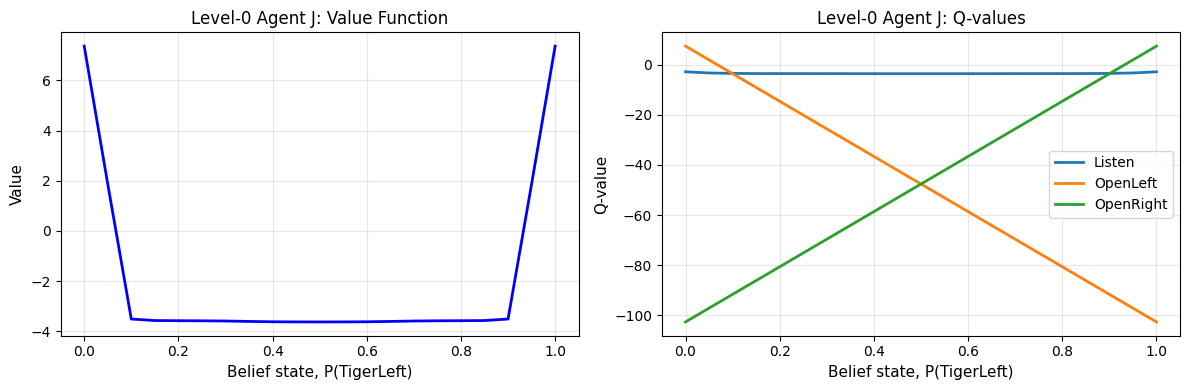

In [165]:
from matplotlib import pyplot as plt
import numpy as onp

# Visualize agent j's value function (level-0 POMDP)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(B_j, v_j, 'b-', linewidth=2)
plt.xlabel('Belief state, P(TigerLeft)', fontsize=11)
plt.ylabel('Value', fontsize=11)
plt.title('Level-0 Agent J: Value Function', fontsize=12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for a in range(3):
    plt.plot(B_j, q_j[:, a], label=action_names[a], linewidth=2)
plt.xlabel('Belief state, P(TigerLeft)', fontsize=11)
plt.ylabel('Q-value', fontsize=11)
plt.title('Level-0 Agent J: Q-values', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

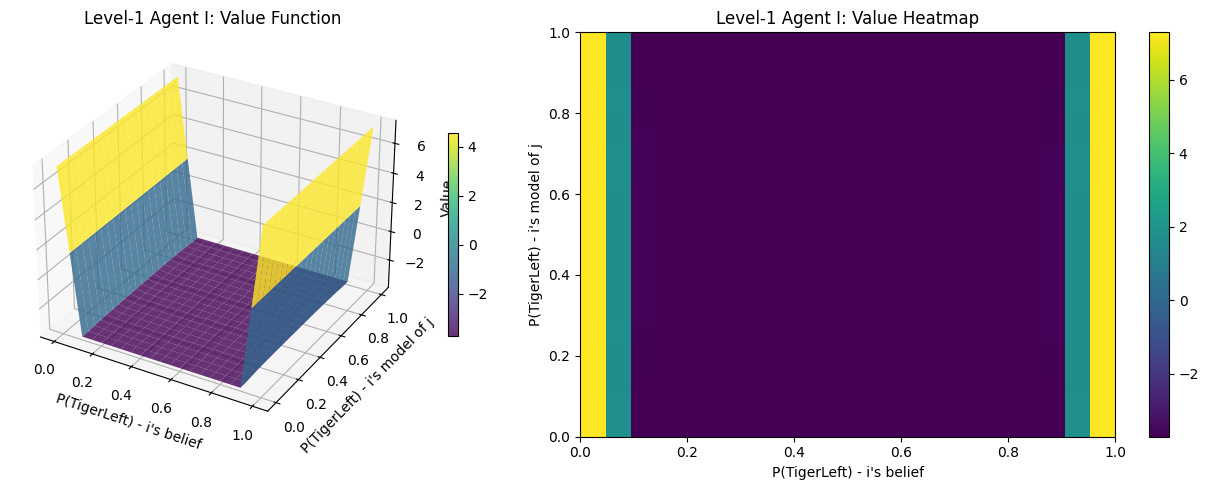

In [166]:
# Visualize agent i's value function (level-1 I-POMDP)
# This is a 3D surface: V(b_i_phys, b_i_model)

v_i = np.max(q_i, axis=2)  # Shape: (21, 21)

fig = plt.figure(figsize=(14, 5))

# 3D surface plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
X, Y = onp.meshgrid(B_i_phys, B_i_model)
surf = ax1.plot_surface(X, Y, onp.array(v_i.T), cmap='viridis', alpha=0.8)
ax1.set_xlabel('P(TigerLeft) - i\'s belief', fontsize=10)
ax1.set_ylabel('P(TigerLeft) - i\'s model of j', fontsize=10)
ax1.set_zlabel('Value', fontsize=10)
ax1.set_title('Level-1 Agent I: Value Function', fontsize=12)
fig.colorbar(surf, ax=ax1, shrink=0.5)

# Heatmap
ax2 = fig.add_subplot(1, 2, 2)
im = ax2.imshow(onp.array(v_i.T), origin='lower', aspect='auto', cmap='viridis',
                extent=[0, 1, 0, 1])
ax2.set_xlabel('P(TigerLeft) - i\'s belief', fontsize=10)
ax2.set_ylabel('P(TigerLeft) - i\'s model of j', fontsize=10)
ax2.set_title('Level-1 Agent I: Value Heatmap', fontsize=12)
fig.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

In [167]:
# Solve level-1 I-POMDP for agent i
print("Solving level-1 I-POMDP for agent i (horizon=3)...")
q_i = Q_i(3)
v_i = np.max(q_i, axis=2)

print("Q-values shape for agent i:", q_i.shape)
print("Value function shape for agent i:", v_i.shape)

Solving level-1 I-POMDP for agent i (horizon=3)...
Q-values shape for agent i: (21, 21, 3)
Value function shape for agent i: (21, 21)


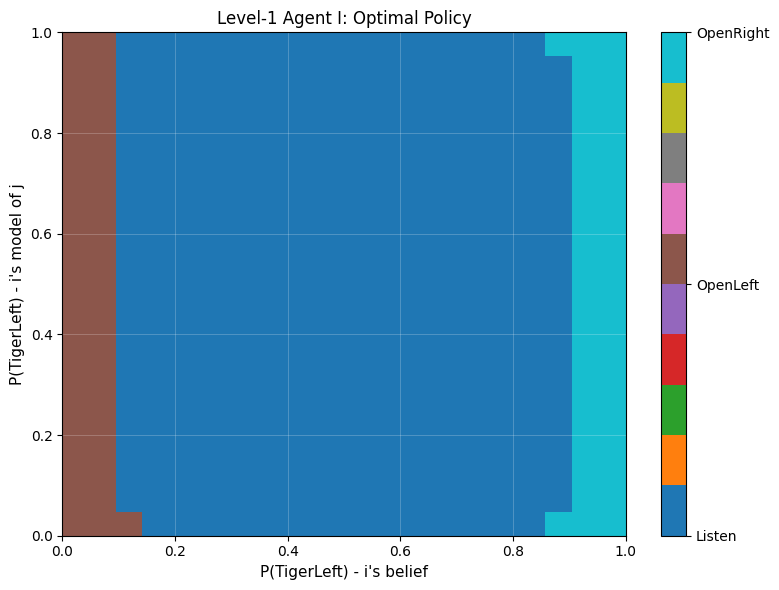

In [168]:
# Visualize optimal policy for agent i
# Show which action is optimal for different belief combinations

optimal_actions_i = np.argmax(q_i, axis=2)  # Shape: (21, 21)

plt.figure(figsize=(8, 6))
im = plt.imshow(onp.array(optimal_actions_i.T), origin='lower', aspect='auto',
                cmap='tab10', vmin=0, vmax=2, extent=[0, 1, 0, 1])
plt.xlabel('P(TigerLeft) - i\'s belief', fontsize=11)
plt.ylabel('P(TigerLeft) - i\'s model of j', fontsize=11)
plt.title('Level-1 Agent I: Optimal Policy', fontsize=12)

# Create custom colorbar
cbar = plt.colorbar(im, ticks=[0, 1, 2])
cbar.set_ticklabels(['Listen', 'OpenLeft', 'OpenRight'])

plt.grid(True, alpha=0.3, color='white', linewidth=0.5)
plt.tight_layout()
plt.show()

# Analysis and Insights

The visualizations above demonstrate several key properties of the I-POMDP solution:

**Agent J (Level-0 POMDP)**:
- Agent j's value function shows the classic symmetric V-shape, minimized at belief 0.5 (maximum uncertainty)
- When j is confident about tiger location (beliefs near 0 or 1), the optimal policy is to open the door believed to contain the prize
- When j is uncertain (beliefs near 0.5), listening is optimal to gather more information
- Agent j treats agent i as environmental noise (uniform random actions)

**Agent I (Level-1 I-POMDP)**:
- Agent i's value function depends on both its physical beliefs (`b_i_phys`) and its model of j's beliefs (`b_i_model`)
- The 3D surface and heatmap show how i's value varies across the interactive belief space
- Agent i engages in strategic reasoning about j's behavior:
  - When i believes j is confident, i predicts j will act (open a door), potentially resetting the state
  - When i believes j is uncertain, i predicts j will continue listening, preserving the state
- The optimal policy shows strategic adaptations:
  - When i is very confident: Open the appropriate door immediately
  - When i is very uncertain: Listen regardless of what j does
  - **In borderline cases** (moderate confidence): i's action depends on what it thinks j will do

**Key Advantage of I-POMDP over POMDP**:

The level-1 agent i uses **forward planning** to predict agent j's behavior based on j's beliefs, enabling strategic decisions that account for:
1. **Dynamic action prediction**: Rather than assuming j acts randomly, i predicts j's actions by reasoning about j's belief state and decision problem
2. **Belief update tracking**: i tracks how j's beliefs evolve based on j's observations, allowing i to predict j's future behavior more accurately
3. **Strategic timing**: In certain belief states (e.g., `b_i_phys=0.10` or `0.90`), knowing whether j will act or listen changes i's optimal decision

This implementation demonstrates a **finitely nested I-POMDP** (level-1), where agent i models agent j as a level-0 POMDP agent. The framework can be extended to higher nesting levels (level-2, level-3, etc.) at the cost of increased computational complexity.